In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os

print("Current directory:", os.getcwd())

data_path = 'hc3_place_cells/ec013.32/ec013.527/ec013.527'

print("Looking for XML at:", data_path + '.xml')
print("File exists:", os.path.exists(data_path + '.xml'))

Current directory: /Users/adireddi/Desktop/CRCNS-neural-analysis
Looking for XML at: hc3_place_cells/ec013.32/ec013.527/ec013.527.xml
File exists: True


In [2]:
tree = ET.parse(data_path + '.xml')
root = tree.getroot()

sampling_rate = int(root.find('.//samplingRate').text)

print(f"Sampling rate: {sampling_rate} Hz")

Sampling rate: 20000 Hz


In [3]:
position = np.loadtxt(data_path + '.whl')

print(f"Position array shape: {position.shape}")
print(f"First 5 rows:")
print(position[:5])

Position array shape: (41411, 4)
First 5 rows:
[[-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]]


OK: hc3_place_cells/ec013.32/ec013.527/ec013.527.xml
OK: hc3_place_cells/ec013.32/ec013.527/ec013.527.whl
OK: hc3_place_cells/ec013.32/ec013.527/ec013.527.res.1
OK: hc3_place_cells/ec013.32/ec013.527/ec013.527.clu.1
OK: hc3_place_cells/ec013.32/ec013.527/ec013.527.res.2
OK: hc3_place_cells/ec013.32/ec013.527/ec013.527.clu.2

Sampling rate: 20000 Hz
1 sample = 0.0500 ms

Position array shape: (41411, 4)
Number of position frames: 41411
First 5 rows (x1 y1 x2 y2):
[[-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]]

Position sampling rate: 39.06 Hz
Total recording duration: 17.67 minutes

Valid position frames: 40554 / 41411
Tracking loss: 2.1% of frames

Shank 1: 53259 spikes, 17 neurons
Shank 2: 33214 spikes, 9 neurons

Total neurons across both shanks: 21
Neuron IDs: [ 2  4  5  6  8  9 10 11 12 13 14 15 17 18 20 21 24 25 26 27 28]

Spike position range:
X: 79.3 to 259.2 pixels
Y: 25.9 to 206.7 pixels


/var/folders/7z/l0p3th1n2x12lwjtz447x9cc0000gn/T/ipykernel_20378/3546920079.py:271: RuntimeWarning: invalid value encountered in divide
  rate_map = np.where(occ_map > 0, spike_map / occ_map, 0)



Neurons with peak rate > 1 Hz: 17 / 21


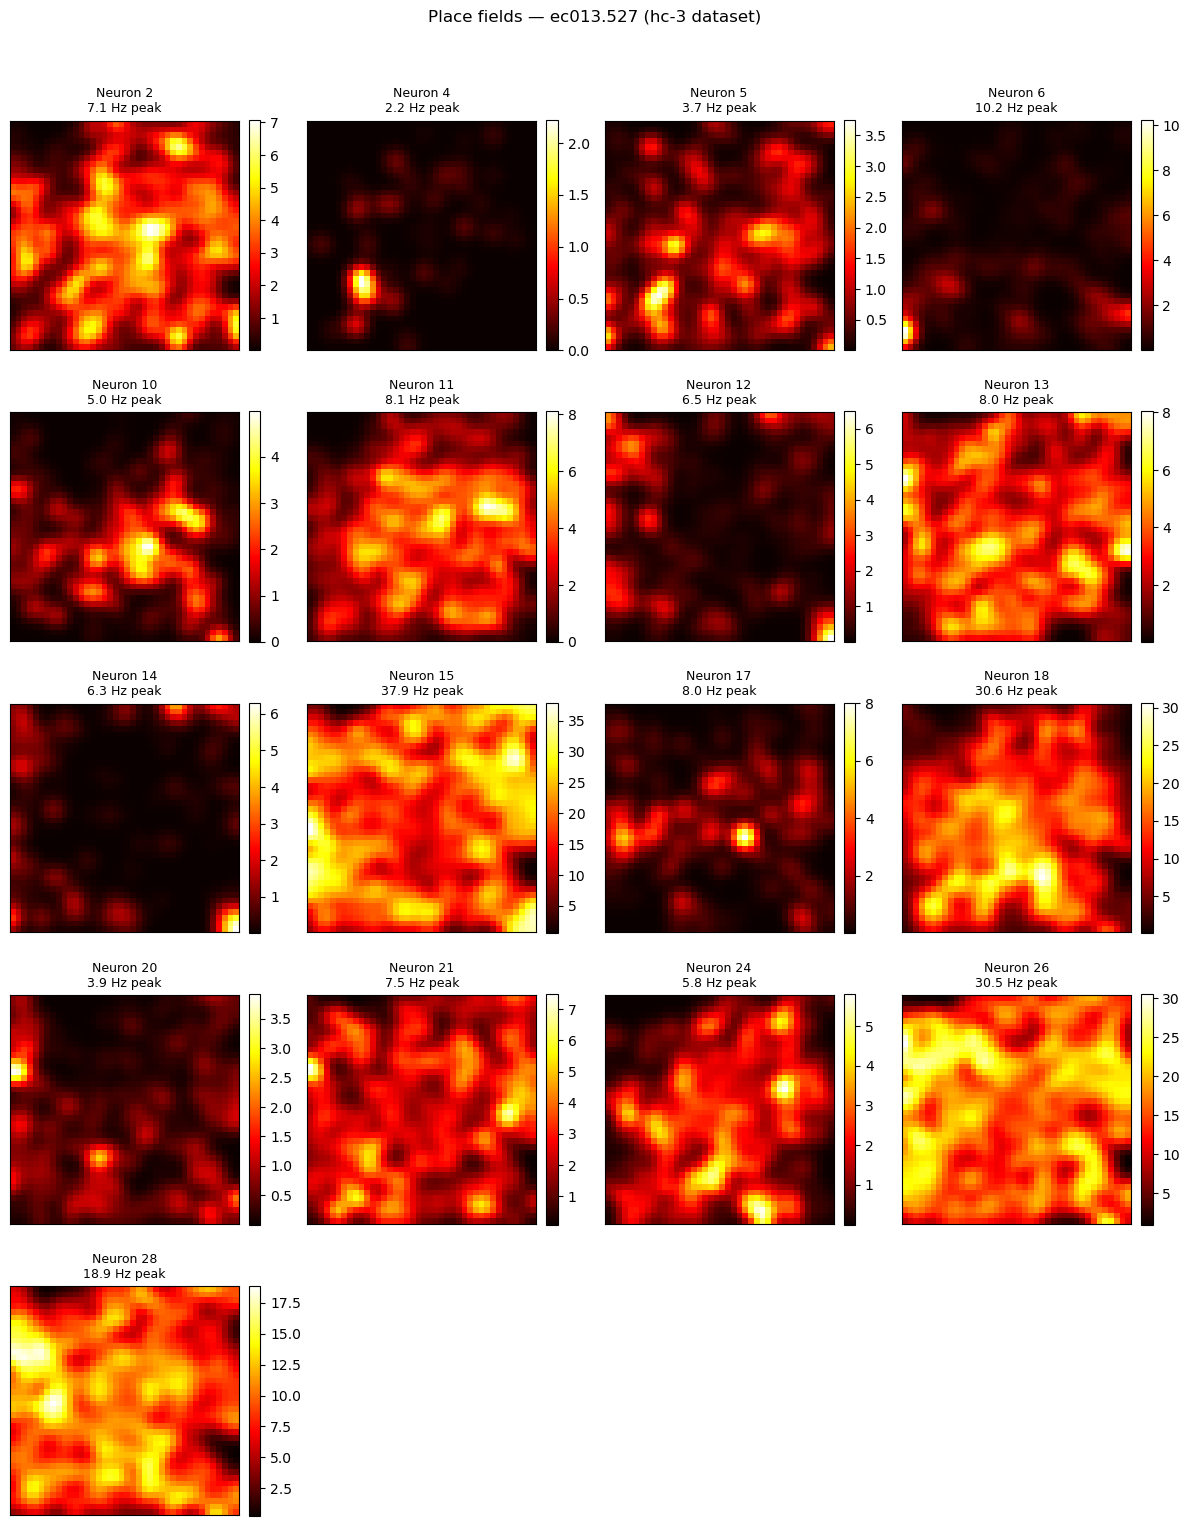

Saved hc3_place_cells/place_fields.png


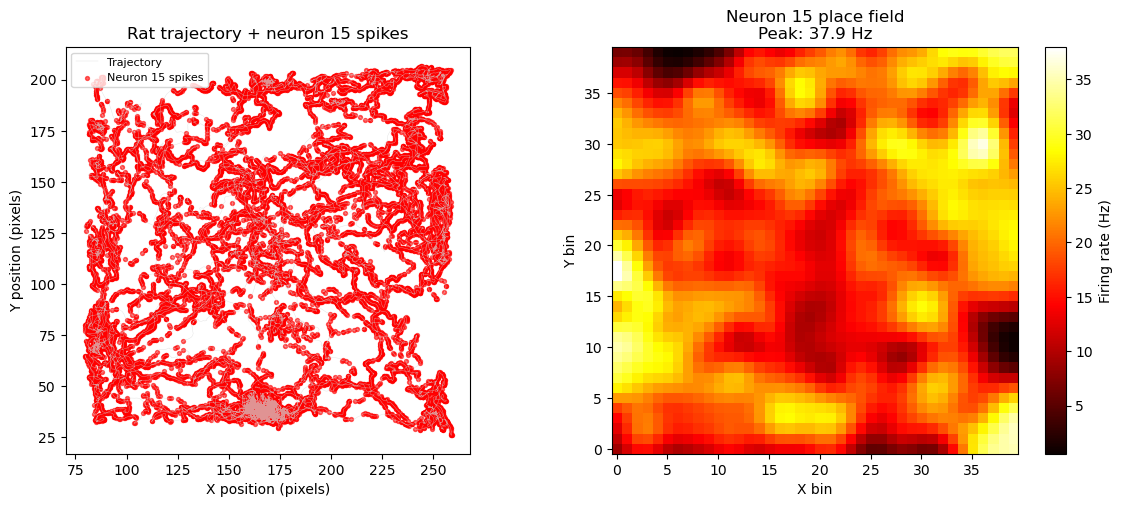

Saved hc3_place_cells/best_place_cell.png

=== Summary ===
Session: ec013.527
Sampling rate: 20000 Hz
Recording duration: 17.67 minutes
Total neurons: 21
Active place cells (>1Hz peak): 17

Top 5 neurons by peak firing rate:
  Neuron 15: 37.93 Hz peak
  Neuron 18: 30.63 Hz peak
  Neuron 26: 30.53 Hz peak
  Neuron 28: 18.90 Hz peak
  Neuron 6: 10.22 Hz peak


In [4]:
"""
place_field_analysis.py
=======================
Place field analysis for hc-3 CRCNS dataset (Buzsaki lab).

Dataset: Multiple single unit recordings from rat hippocampal and
entorhinal regions (Mizuseki et al., F1000Research 2014).

Session used: ec013.527
Files needed:
    ec013.527.xml   — metadata (sampling rate)
    ec013.527.whl   — rat position tracking
    ec013.527.res.1 — spike times, shank 1
    ec013.527.clu.1 — neuron IDs, shank 1
    ec013.527.res.2 — spike times, shank 2
    ec013.527.clu.2 — neuron IDs, shank 2

Download from: https://portal.nersc.gov/project/crcns/download/hc-3
Requires free CRCNS account.

Usage: run each cell in order in Jupyter notebook.

Citation:
Mizuseki, K., Sirota, A., Pastalkova, E., Diba, K., Buzsáki, G. (2013)
Multiple single unit recordings from different rat hippocampal and
entorhinal regions while the animals were performing multiple behavioral
tasks. CRCNS.org. http://dx.doi.org/10.6080/K09G5JRZ
"""

import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os

# ── Path setup ────────────────────────────────────────────────────────────────

data_path = 'hc3_place_cells/ec013.32/ec013.527/ec013.527'

# Quick check all files exist before we start
required_files = ['.xml', '.whl', '.res.1', '.clu.1', '.res.2', '.clu.2']
for ext in required_files:
    fpath = data_path + ext
    exists = os.path.exists(fpath)
    print(f"{'OK' if exists else 'MISSING'}: {fpath}")

# ── Section 1: Load metadata ──────────────────────────────────────────────────

tree = ET.parse(data_path + '.xml')
root = tree.getroot()

# Sampling rate tells us how many samples = 1 second
# spike_time_in_seconds = sample_number / sampling_rate
sampling_rate = int(root.find('.//samplingRate').text)
print(f"\nSampling rate: {sampling_rate} Hz")
print(f"1 sample = {1/sampling_rate*1000:.4f} ms")

# ── Section 2: Load position data ─────────────────────────────────────────────

# .whl file has 4 columns: x1 y1 x2 y2
# x1,y1 = position of LED 1 on rat's head
# x2,y2 = position of LED 2 on rat's head
# -1 values mean camera lost track of the rat that frame
# Position is sampled at ~39.06 Hz (every 512 samples at 20kHz)
position_raw = np.loadtxt(data_path + '.whl')

print(f"\nPosition array shape: {position_raw.shape}")
print(f"Number of position frames: {position_raw.shape[0]}")
print(f"First 5 rows (x1 y1 x2 y2):\n{position_raw[:5]}")

# Position sampling rate — one position frame every 512 electrophysiology samples
pos_sampling_rate = sampling_rate / 512
print(f"\nPosition sampling rate: {pos_sampling_rate:.2f} Hz")
print(f"Total recording duration: {position_raw.shape[0] / pos_sampling_rate / 60:.2f} minutes")

# Use the midpoint of the two LEDs as the rat's position
# This is more robust than using either LED alone
x1 = position_raw[:, 0]   # column 0 — x coordinate of LED 1
y1 = position_raw[:, 1]   # column 1 — y coordinate of LED 1
x2 = position_raw[:, 2]   # column 2 — x coordinate of LED 2
y2 = position_raw[:, 3]   # column 3 — y coordinate of LED 2

# Midpoint x and y
x_mid = (x1 + x2) / 2
y_mid = (y1 + y2) / 2

# Create a valid frames mask — frames where camera tracked the rat
# -1 means lost tracking, so valid frames have both LEDs above 0
valid = (x1 > 0) & (y1 > 0) & (x2 > 0) & (y2 > 0)

print(f"\nValid position frames: {valid.sum()} / {len(valid)}")
print(f"Tracking loss: {100*(~valid).mean():.1f}% of frames")

# Replace invalid frames with NaN so they don't affect analysis
x_mid[~valid] = np.nan
y_mid[~valid] = np.nan

# ── Section 3: Load spike data ────────────────────────────────────────────────

def load_spikes(res_file, clu_file):
    """
    Load spike times and neuron IDs from .res and .clu files.

    The .res file contains one spike time per line in samples.
    The .clu file contains one neuron ID per line.
    First line of .clu is the total number of clusters — skip it.
    Cluster 0 and 1 are noise/unsorted — skip those too.

    Parameters
    ----------
    res_file : str
        Path to .res file
    clu_file : str
        Path to .clu file

    Returns
    -------
    spike_times : 1D numpy array of spike times in samples
    spike_ids   : 1D numpy array of neuron IDs for each spike
    n_neurons   : int, number of sorted neurons
    """
    # np.loadtxt reads a plain text file into a numpy array
    # dtype=int because spike times and cluster IDs are always integers
    spike_times = np.loadtxt(res_file, dtype=int)

    # clu file has n_clusters on the first line, then one ID per spike
    clu_raw = np.loadtxt(clu_file, dtype=int)

    # First line is the total cluster count, not a real spike
    n_clusters = clu_raw[0]
    spike_ids  = clu_raw[1:]   # everything after the first line

    # Cluster 0 = noise, cluster 1 = unsorted multi-unit activity
    # We only want clusters 2 and above — properly sorted single units
    good = spike_ids >= 2
    spike_times = spike_times[good]
    spike_ids   = spike_ids[good]

    # Real neuron count is clusters minus the 2 noise clusters
    n_neurons = n_clusters - 2

    return spike_times, spike_ids, n_neurons


# Load both shanks
spike_times_s1, spike_ids_s1, n_neurons_s1 = load_spikes(
    data_path + '.res.1', data_path + '.clu.1')

spike_times_s2, spike_ids_s2, n_neurons_s2 = load_spikes(
    data_path + '.res.2', data_path + '.clu.2')

print(f"\nShank 1: {spike_times_s1.shape[0]} spikes, {n_neurons_s1} neurons")
print(f"Shank 2: {spike_times_s2.shape[0]} spikes, {n_neurons_s2} neurons")

# Combine both shanks into one dataset
# np.concatenate joins arrays end to end along an axis
all_spike_times = np.concatenate([spike_times_s1, spike_times_s2])

# Add an offset to shank 2 neuron IDs so they don't overlap with shank 1
# e.g. if shank 1 has neurons 2-8, shank 2 neurons become 9-15
spike_ids_s2_offset = spike_ids_s2 + spike_ids_s1.max()
all_spike_ids = np.concatenate([spike_ids_s1, spike_ids_s2_offset])

# Sort everything by time so spikes are in chronological order
sort_idx = np.argsort(all_spike_times)
all_spike_times = all_spike_times[sort_idx]
all_spike_ids   = all_spike_ids[sort_idx]

unique_neurons = np.unique(all_spike_ids)
print(f"\nTotal neurons across both shanks: {len(unique_neurons)}")
print(f"Neuron IDs: {unique_neurons}")

# ── Section 4: Convert spike times to position ────────────────────────────────

# Spike times are in electrophysiology samples (20kHz)
# Position frames are sampled every 512 electrophysiology samples
# So: position_frame_index = spike_sample // 512
# The // operator is integer division — rounds down to nearest whole number
# e.g. sample 1000 // 512 = 1 (frame 1), sample 2048 // 512 = 4 (frame 4)

spike_pos_idx = all_spike_times // 512

# Clip to valid range — make sure no index goes beyond the position array length
# This handles edge cases at the very end of the recording
spike_pos_idx = np.clip(spike_pos_idx, 0, len(x_mid) - 1)

# Get the x,y position of the rat at the moment each spike occurred
spike_x = x_mid[spike_pos_idx]
spike_y = y_mid[spike_pos_idx]

print(f"\nSpike position range:")
print(f"X: {np.nanmin(spike_x):.1f} to {np.nanmax(spike_x):.1f} pixels")
print(f"Y: {np.nanmin(spike_y):.1f} to {np.nanmax(spike_y):.1f} pixels")

# ── Section 5: Build place fields ─────────────────────────────────────────────

def compute_place_field(neuron_id, spike_ids, spike_x, spike_y,
                        x_mid, y_mid, valid, n_bins=40, sigma=1.5):
    """
    Compute a smoothed place field (firing rate map) for one neuron.

    The place field is a 2D grid where each cell contains the firing
    rate of the neuron when the rat was in that region of the environment.

    firing_rate[x,y] = spikes_in_cell[x,y] / time_spent_in_cell[x,y]

    Parameters
    ----------
    neuron_id : int
        Which neuron to compute the place field for
    spike_ids : 1D array
        Neuron ID for each spike
    spike_x, spike_y : 1D arrays
        Position of rat at each spike
    x_mid, y_mid : 1D arrays
        Full position timeseries (all frames)
    valid : 1D boolean array
        Which position frames are valid (camera tracked the rat)
    n_bins : int
        Number of spatial bins in each dimension (40x40 grid)
    sigma : float
        Smoothing kernel width in bins

    Returns
    -------
    rate_map : 2D array of shape (n_bins, n_bins)
        Firing rate in Hz at each spatial location
    """
    from scipy.ndimage import gaussian_filter

    # Get x,y range from the full position data (not just spike positions)
    x_valid = x_mid[valid]
    y_valid = y_mid[valid]
    x_min, x_max = np.nanmin(x_valid), np.nanmax(x_valid)
    y_min, y_max = np.nanmin(y_valid), np.nanmax(y_valid)

    # Define bin edges spanning the full environment
    x_edges = np.linspace(x_min, x_max, n_bins + 1)
    y_edges = np.linspace(y_min, y_max, n_bins + 1)

    # Find spikes from this neuron only
    # == is the equality comparison operator, returns a boolean array
    neuron_mask = spike_ids == neuron_id

    # Get positions of this neuron's spikes
    nx = spike_x[neuron_mask]
    ny = spike_y[neuron_mask]

    # Remove NaN positions (spikes during tracking loss)
    # np.isnan returns True where value is NaN
    # ~ is the "not" operator for boolean arrays
    pos_valid = ~(np.isnan(nx) | np.isnan(ny))
    nx = nx[pos_valid]
    ny = ny[pos_valid]

    # Count spikes in each spatial bin
    # np.histogram2d counts how many (x,y) points fall in each 2D bin
    spike_map, _, _ = np.histogram2d(nx, ny, bins=[x_edges, y_edges])

    # Count how much time the rat spent in each spatial bin
    # This is the occupancy map — needed to convert spike counts to rates
    # Position frame duration = 1 / pos_sampling_rate seconds
    frame_duration = 512 / sampling_rate   # seconds per position frame
    occ_map, _, _ = np.histogram2d(
        x_mid[valid], y_mid[valid],
        bins=[x_edges, y_edges])
    occ_map = occ_map * frame_duration     # convert frames to seconds

    # Firing rate = spikes / time
    # Where occupancy is 0 (rat never visited), rate is undefined — set to 0
    # np.where(condition, value_if_true, value_if_false)
    rate_map = np.where(occ_map > 0, spike_map / occ_map, 0)

    # Smooth the rate map with a Gaussian filter
    # This removes noise from sparse sampling and makes place fields look cleaner
    # sigma controls smoothing strength — larger = smoother
    rate_map = gaussian_filter(rate_map, sigma=sigma)

    return rate_map


# ── Section 6: Plot place fields for all neurons ──────────────────────────────

# Compute place fields for all neurons
place_fields = {}
for nid in unique_neurons:
    place_fields[nid] = compute_place_field(
        nid, all_spike_ids, spike_x, spike_y,
        x_mid, y_mid, valid)

# Find neurons with meaningful place fields
# A good place cell has a peak firing rate above 1 Hz
active_neurons = [nid for nid, pf in place_fields.items()
                  if pf.max() > 1.0]
print(f"\nNeurons with peak rate > 1 Hz: {len(active_neurons)} / {len(unique_neurons)}")

# Plot place fields in a grid
n_plot = len(active_neurons)
n_cols = 4
n_rows = int(np.ceil(n_plot / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 3, n_rows * 3))

# axes.flatten() converts the 2D grid of axes into a 1D list
# so we can loop through them with a simple for loop
axes_flat = axes.flatten() if n_plot > 1 else [axes]

for i, nid in enumerate(active_neurons):
    ax = axes_flat[i]
    pf = place_fields[nid]

    # .T transposes the array — swaps rows and columns
    # This makes x go left-right and y go up-down in the plot
    im = ax.imshow(pf.T, origin='lower', cmap='hot',
                   aspect='equal', interpolation='nearest')

    ax.set_title(f'Neuron {nid}\n{pf.max():.1f} Hz peak', fontsize=9)
    ax.set_xticks([])   # remove x tick marks — pixel units aren't meaningful
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Hide any unused subplot panels
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Place fields — ec013.527 (hc-3 dataset)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('hc3_place_cells/place_fields.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved hc3_place_cells/place_fields.png")

# ── Section 7: Plot rat trajectory with spike overlay ────────────────────────

# Pick the neuron with the highest peak firing rate
best_neuron = max(active_neurons, key=lambda nid: place_fields[nid].max())
best_mask = all_spike_ids == best_neuron
bx = spike_x[best_mask]
by = spike_y[best_mask]
pos_valid_mask = ~(np.isnan(bx) | np.isnan(by))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — rat trajectory with spike locations overlaid
axes[0].plot(x_mid[valid], y_mid[valid],
             color='lightgray', linewidth=0.3, alpha=0.7, label='Trajectory')
axes[0].scatter(bx[pos_valid_mask], by[pos_valid_mask],
                s=8, c='red', alpha=0.6, label=f'Neuron {best_neuron} spikes')
axes[0].set_title(f'Rat trajectory + neuron {best_neuron} spikes')
axes[0].set_xlabel('X position (pixels)')
axes[0].set_ylabel('Y position (pixels)')
axes[0].legend(fontsize=8)
axes[0].set_aspect('equal')

# Right — place field heatmap of best neuron
im = axes[1].imshow(place_fields[best_neuron].T,
                     origin='lower', cmap='hot',
                     aspect='equal', interpolation='nearest')
axes[1].set_title(f'Neuron {best_neuron} place field\nPeak: {place_fields[best_neuron].max():.1f} Hz')
axes[1].set_xlabel('X bin')
axes[1].set_ylabel('Y bin')
plt.colorbar(im, ax=axes[1], label='Firing rate (Hz)')

plt.tight_layout()
plt.savefig('hc3_place_cells/best_place_cell.png', dpi=150)
plt.show()
print(f"Saved hc3_place_cells/best_place_cell.png")

# ── Section 8: Summary statistics ────────────────────────────────────────────

print("\n=== Summary ===")
print(f"Session: ec013.527")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Recording duration: {position_raw.shape[0] / pos_sampling_rate / 60:.2f} minutes")
print(f"Total neurons: {len(unique_neurons)}")
print(f"Active place cells (>1Hz peak): {len(active_neurons)}")
print(f"\nTop 5 neurons by peak firing rate:")
sorted_neurons = sorted(active_neurons,
                        key=lambda nid: place_fields[nid].max(),
                        reverse=True)
for nid in sorted_neurons[:5]:
    print(f"  Neuron {nid}: {place_fields[nid].max():.2f} Hz peak")